# Exercise 1: data blocking

In [31]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

## 1.1
**Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:**
1. **$\langle r \rangle = \int_0^1 r dr = 1/2$. Make a picture of the estimation of $\langle r \rangle$ and its uncertainty  with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$**
2. **$\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$**
3.  **Divide $[0,1]$ into $M$ identical sub-intervals and implement the $\chi^2$ test.Obviously, the number of expected events observed in each sub-interval after $n$ *throws*, according to a uniform distribution, is $np = n\times 1/M= n/M$. Fix $M=10^2$ and use for $n$ the first $10^4$ pseudo-random numbers, then the successive $10^4$ pseudo-random numbers, and so on ... 100 times. Plot $\chi^2_j$ for $j=1, ..., 100$. In this case the chi-square statistic is:
$$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$**

#### Estimating the integrals
To simplify the implementation of the data blocking technique, I defined a statistics structure that stores block averages, progressive averages, and their squared values, and includes a method to compute the statistical error on the progressive mean.
```c++
struct statistics {
    double ave = 0.0;        // average of current block
    double ave2 = 0.0;       // square of the average
    double block_ave = 0.0;  // cumulative average over blocks
    double block_ave2 = 0.0; // cumulative square average over blocks
    double err = 0.0;        // statistical error

    // Reset quantities for a new block
    void reset() {
        ave = 0.0;
        ave2 = 0.0;
        err = 0.0;
    }

    // Compute statistical error using progressive averages
    void compute_err(int n) { //n is block index+1
        if (n == 1)
            err = 0.0;
        else
            err = sqrt((block_ave2 / n - pow(block_ave / n, 2)) / double(n - 1));
    }

    // Update cumulative quantities
    void increment_block(int N) {//N is block length
        ave /= N;
        ave2 = ave * ave;
        block_ave += ave;
        block_ave2 += ave2;
    }
    
};



To estimate the integral, I generated $10^4$ random numbers uniformly distributed in the interval [0,1) and computed their average. This procedure was repeated over 100 blocks to obtain progressive estimates and uncertainties, which are shown in the plots below for both $\langle r \rangle$ and $\langle \sigma^2 \rangle$

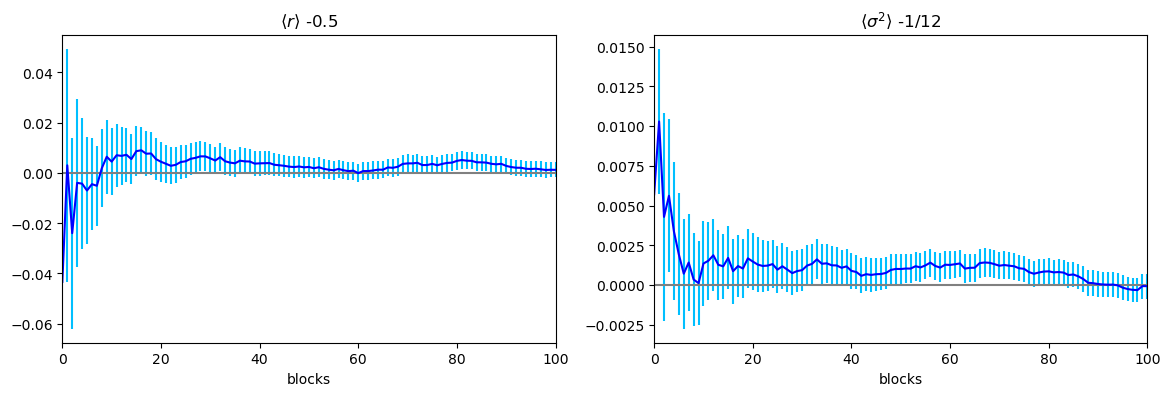

In [32]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
df = pd.read_csv('./OUTPUT/integral.csv', sep = '\t')
ax[0].errorbar(df['block'], df['block_ave']-0.5,yerr=df['err'],color='blue',ecolor='deepskyblue')

df = pd.read_csv('./OUTPUT/variance.csv', sep = '\t')
ax[1].errorbar(df['block'], df['block_ave']-1/12, yerr=df['err'],color='blue',ecolor='deepskyblue')

for axes in ax:
    axes.set_xlabel('blocks')
    axes.hlines(0,100,0,color='gray')
    axes.set_xlim(0,100)

ax[0].set_title(r"$\langle r \rangle$ -0.5")
ax[1].set_title(r"$\langle \sigma^2 \rangle$ -1/12")

plt.show()



In both cases the last block average values are compatible with the expected ones within one standard deviation, so we can assume that the hypothesis of the uniformity of the random generator is valid.

#### $\chi^2$ evaluation
For the evaluation of the $\chi^2$, I used two nested *for* loops. At each iteration of the outer loop, a value $\chi^2_j$ is computed by evaluating the sum in the equation above. For each subinterval into which the interval $[0,1)$ is divided, $10^4$ random numbers are generated and the number of values $n_i$ falling within the considered interval is counted.

From the plots below, we observe that the resulting $\chi_j$ values are scattered around the expected value $\langle \chi^2 \rangle = 100$.


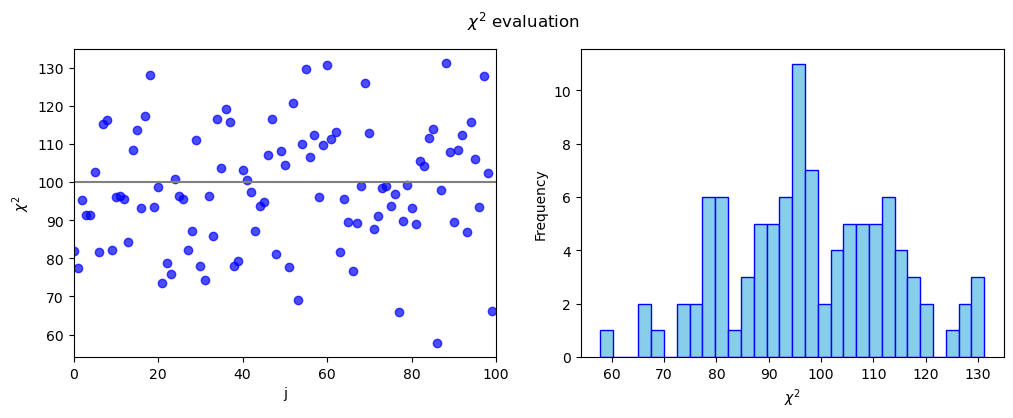

In [79]:
dfc= pd.read_csv('./OUTPUT/Chi.csv',sep='\t')
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].scatter(dfc['j'],dfc['chi_j'],color='blue',alpha=0.7)
ax[0].hlines(100,-1,101,color='gray')
ax[0].set_xlim(0,100)
ax[0].set_ylabel(r'$\chi^2$')
ax[0].set_xlabel('j')

ax[1].hist(dfc['chi_j'],bins =30,edgecolor='blue',color='skyblue')
ax[1].set_xlabel(r'$\chi^2$')
ax[1].set_ylabel('Frequency')
fig.suptitle(r'$\chi^2$ evaluation')

plt.show()

## 1.2
1. **Add two probability distributions by using the method of the inversion of the cumulative distribution to sample from a generic exponential distribution, $p(x) = \lambda \exp(-\lambda x)$, $x\in [0;+\infty]$, and a **generic** Cauchy-Lorentz distribution $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$, $x\in [-\infty;+\infty]$.**
2. **Make 3 pictures with the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).**

It is possible to show that for any probability distribution $p(x)$, its cumulative distribution function $F(x)$, defined as
$
F(x) = \int_{-\infty}^{x} p(t)\,dt,
\quad \text{with} \quad
p(x) = \frac{dF(x)}{dx},
$
is uniformly distributed in the interval $[0,1]$.

Therefore, if a random variable $y$ is extracted from a uniform distribution in $[0,1]$ and the inverse cumulative distribution function is applied, one obtains a random variable distributed according to the desired probability density. In other words,
$
x = F^{-1}(y)
$
is distributed according to the desired $p(x)$.


In [23]:
def plot_hist(p_type):
    df = pd.read_csv(f"./OUTPUT/SN_{p_type}.csv", sep ='\t')
    N_values = df['N'].unique()
    cmap = plt.colormaps['Blues']
    colors = cmap(np.linspace(0, 1, len(N_values)+1))
    fig,ax= plt.subplots(1,4,figsize=(16,4))

    for i,val in enumerate(N_values):
        if (p_type=='Cauchy-Lorentz'):bins=1000
        else: bins =None
        ax[i].hist(df[df['N'] == val]['SN'],  color=colors[i+1],label=f'N = {val}',density=True,edgecolor='darkblue',bins=bins)
        ax[i].legend()
        if (p_type=='Cauchy-Lorentz'): ax[i].set_xlim(-200,200)
  
    fig.suptitle(f'{p_type}')
    

#### Standard dice
In this case to estimate $S_N$ I just used the standard method of the random generator to extract a number between 0 and 1 with a uniform probability.

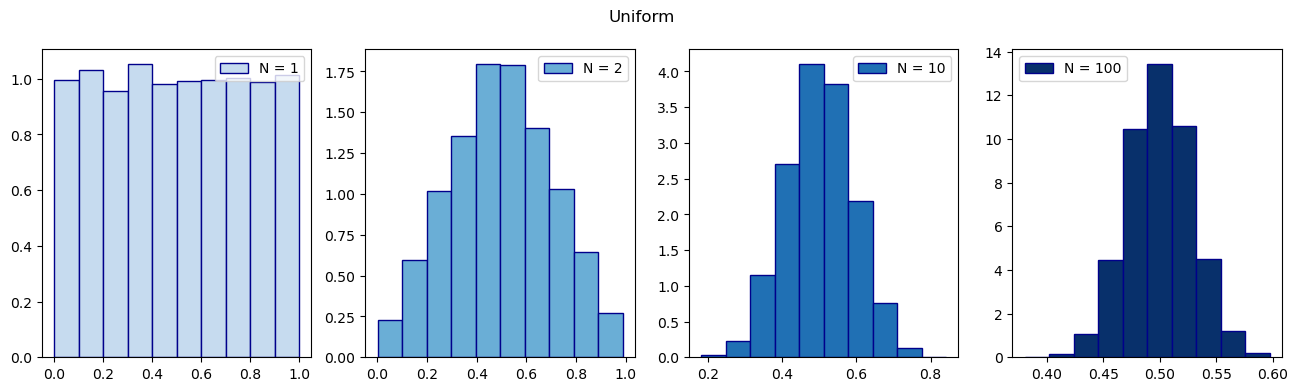

In [6]:
plot_hist('Uniform')

#### Exponential dice
An exponential dice generates a random number distributed like $\lambda e^{-\lambda x}$. In this case we have:
$$F^{-1}(y) = -\frac{1}{\lambda} ln (1-y)$$
Therefore I add an exponential generator to the random class implementing: 
```c++
double Random :: Exp (double lambda) {
  double r=Rannyu();
  return (-1./lambda)*log(1-r);
}

And computed the values of $S_N$ just like before, considering $\lambda = 1$:

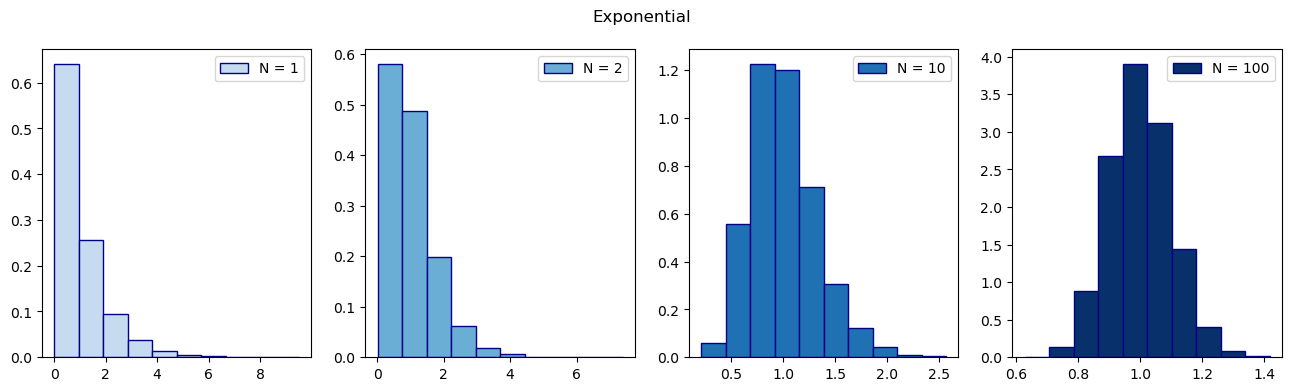

In [17]:
plot_hist('Exponential')

#### Lorentzian dice
The Cauchy-Lorentz distribution is the distribution of the x-intercept of a ray issuing from ($\mu$,$\Gamma$) with a uniformly distributed angle. The inverse of its cumulative is:
$$ F^{-1}(y)= \mu +\Gamma \tan \big[\pi(y-\frac{1}
{2}\big] $$
I extracted values from this distribution with $\mu=0$ and $\Gamma=1$ using the following function I added to the generator:
```c++
double Random :: Cauchy (double mu, double gamma) {
  double r=Rannyu();
  return mu + gamma * tan(M_PI*(r-0.5));
}


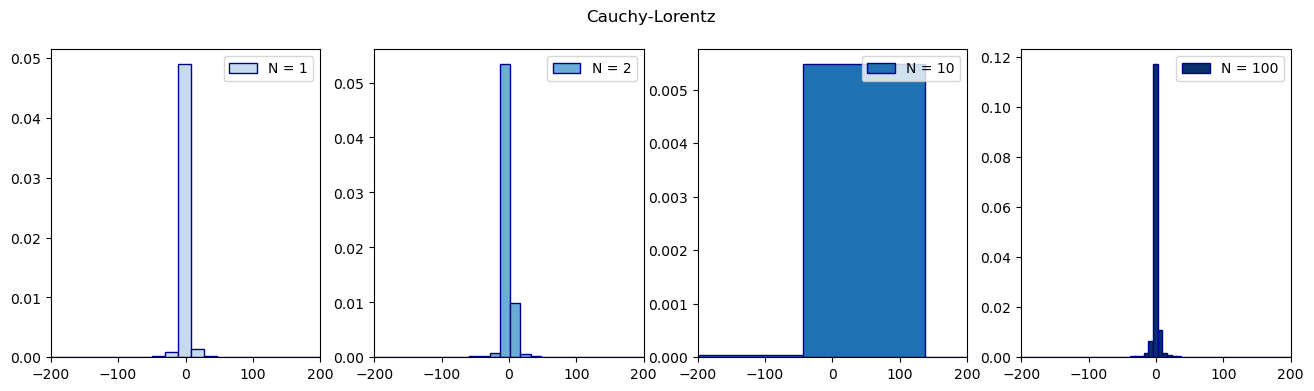

In [24]:
plot_hist('Cauchy-Lorentz')

We observe that, in the case of the uniform and exponential dice, the distribution of the sum approaches a Gaussian as the number of throws increases, in agreement with the central limit theorem (CLT). One of the conditions for the validity of the CLT is that the underlying probability density function has a finite variance, a requirement that is not satisfied by the Cauchy–Lorentz distribution.
Indeed, it can be shown that, for large $N$, the sum of $N$ independent Cauchy–Lorentz random variables converges to a Cauchy–Lorentz distribution. This behavior can be understood within the framework of the generalized central limit theorem, which states that, for a wide class of probability density functions, the properly rescaled sum of random variables converges to a stable distribution (attractor) in the limit of large $N$. Both the Gaussian and the Cauchy–Lorentz distributions are examples of such attractors.


## 1.3
**Simulate the Buffon’s experiment:  A needle of length $L$ is thrown at random onto a horizontal plane ruled with straight lines a distance $d$ (must be $d > L$, but do not use $d\gg L$ otherwise $P\ll 1$) apart. The probability $P$ that the needle will intersect one of these lines is: $P = 2L/\pi d$. This could be used to evaluate $\pi$ from throws of the needle: if the needle is thrown down $N_{thr}$ times and is observed to land on a line $N_{hit}$ of those times, we can make an estimate of $\pi$ from
$$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$
Make a picture of the estimation of $\pi$ and its uncertainty (Standard Deviation of the mean) with a large number of *throws* $M$ as a function of the number of blocks, $N$. If possible, do not use $\pi$ to evaluate $\pi$.**

Since the problem is periodic, it is sufficient to consider only the intersections of the needle with the lines $y = 0$ and $y = D$.

The first endpoint of the needle is generated uniformly at random in the interval $[0, D]$. For the second endpoint, random Cartesian components are extracted as
$
x = R \sin\theta \in [0, D], \qquad y = R \cos\theta \in [-1, 1],
$
from which the norm $R$ is computed. The effective inclination of the needle is then obtained by computing
$
\sin\theta = \frac{R \sin\theta}{R}.
$

Once the coordinates of the two endpoints of the needle are known, checking whether it intersects one of the lines is straightforward. This procedure is repeated over 100 blocks of $10^4$ throws to perform the statistical analysis.

Additionally, a set of randomly generated values of $x$ was produced to provide a visual representation of the geometric setup.


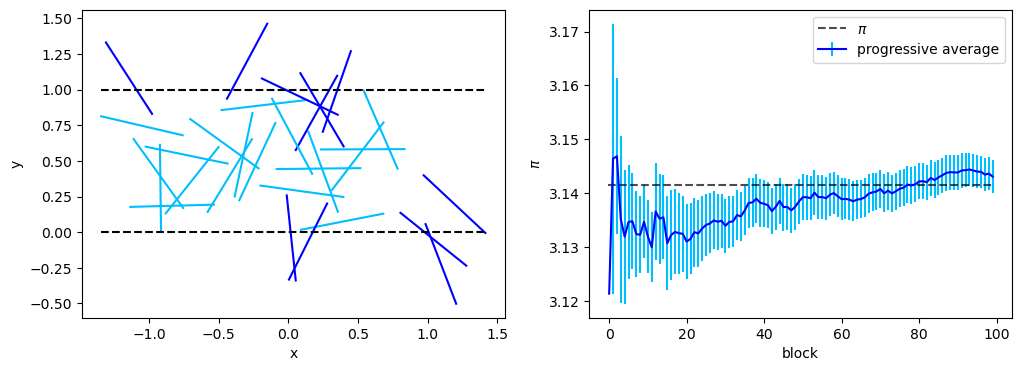

In [35]:
import matplotlib.pyplot as plt

df = pd.read_csv('./OUTPUT/positions.csv',sep='\t')
fig,ax=plt.subplots(1,2,figsize=(12,4))
for i in range(len(df['xmin'])):
    if(df['hit'][i]==1) :col='blue'
    else :col='deepskyblue'
    ax[0].plot([df['xmin'][i], df['xmax'][i]], [df['ymin'][i], df['ymax'][i]],color=col) 
ax[0].hlines(0,np.min(df['xmax']),np.max(df['xmax']),color='black',linestyle='dashed')
ax[0].hlines(1,np.min(df['xmax']),np.max(df['xmax']),color='black',linestyle='dashed')
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
df1=pd.read_csv("./OUTPUT/pi_ave.csv",sep='\t')
ax[1].errorbar(df1['block'],df1['block_ave'],yerr=df1['err'],label='progressive average',color='blue',ecolor='deepskyblue')
ax[1].hlines(np.pi,np.min(df1['block'])-0.2,np.max(df1['block']),color='black',alpha=0.7,label = r'$\pi$',linestyle='dashed')
ax[1].set_xlabel('block')
ax[1].set_ylabel(r'$\pi$')
ax[1].legend()
plt.show()
